Class balance/distribution/proportion of the target is: target_5
0    0.522887
1    0.477113


    model = RandomForestClassifier(n_estimators=300, max_depth=5, 'max_features': 'sqrt' random_state=42)

    
Name: proportion, dtype: float64

        Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
20 % top score using mean is : 0.5934065934065934 

20 % bottom score using mean is : 0.34065934065934067

accuracy_score is : 0.5775577557755776
 Train accuracy is : 0.7397524071526822
  Test accuracy is : 0.5775577557755776

[[386 104]
 [280 139]]
              precision    recall  f1-score   support

           0       0.58      0.79      0.67       490
           1       0.57      0.33      0.42       419

accuracy_score                         0.58       909
macro avg          0.58      0.56     0.54        909
weighted avg       0.58      0.58     0.55        909

looking for a model where following parametres were tested : 

param_grid = {
    "max_depth": [3, 4,5],
    "min_samples_leaf": [5, 10, 20]
}

results

Model name is : RandomForestClassifier, model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 
'max_depth': 3,
 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0,
  'min_samples_leaf': 5, 
 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

 20 % top score using mean is : 0.5439560439560439 
 20 % bottom score using mean is : 0.37362637362637363 

 accuracy_score is : 0.5544554455445545 
 Train accuracy is : 0.6275103163686382
 Test accuracy is : 0.5544554455445545


 [[399 91] 
 [314 105]]

            precision       Recall      f1-score        support
            0   0.56           0.81          0.66           490
            1   0.54           0.25          0.34           419 
  
  
  accuracy                        0.55                       909 
  macro avg   0.55              0.53        0.50              909 
  weighted avg 0.55              0.55     0.51                909

| Model  | Recall (0) | Recall (1)   |
| ------ | ---------- | ------------ |
| before | 0.79       | 0.30         |
| after  | **0.81** ↑ | **0.25** ↓ ❌ |


based on recall Model is always advsing  0 if its not sure.  , look on False NEgative : 314 
not many True Positives : only 105 , decrease from 139 

max_depth=3
min_samples_leaf=5

makes the model simplier, 

less overfitting : 

 before  : Train accuracy is : 0.7397524071526822

 After :   Train accuracy is : 0.6275103163686382

before 

[[386 104]
 [280 139]]

 after 
 
  [[399 91] 
 [314 105]]

 more  TN and less TP

Recall up for class 0 ,down for class 1 

model learns less and is choosing the save path



testing the max_depth and moin_samples_lift : 


max_depth=4
min_samples_leaf=2-3


becasue : 


Parametr                    	        Efekt
większy max_depth	                    ↑ recall, ↓ precision
mniejszy max_depth	                    ↑ precision, ↓ recall
mniejszy min_samples_leaf	            ↑ recall, ↓ precision
większy min_samples_leaf	            ↑ precision, ↓ recall


and adding the class_weight="balanced"

becasue the model learns to tream with higher priority mistakes on the favoured class

reuslt : 

Model name is : RandomForestClassifier, 
model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 
'class_weight': 'balanced',
 'criterion': 'gini', 
 'max_depth': 4, 
 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 
 'min_samples_leaf': 2,
  'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False} 
  
  20 % top score using mean is : 0.5494505494505495
20 % bottom score using mean is : 0.34615384615384615
 accuracy_score is : 0.5676567656765676 
 Train accuracy is : 0.6544704264099037 
 Test accuracy is : 0.5676567656765676

 [[345 145] 
 [248 171]]
            Precision   Recall    f1-score    support 
  0           0.58        0.70       0.64       490 
  1           0.54         0.41      0.47       419 
  
  accuracy                            0.57      909
  macro avg   0.56         0.56       0.55      909
  weighted avg 0.56        0.57       0.56      909

confusion matrix change 

 from 

  [[399 91] 
 [314 105]]

 into 

  [[345 145] 
 [248 171]]

 more TP , less FN (294 -> 248 )

 Recall  change  for class 1 

 from 0,25 to 0,41 - model is cathcing the singal

 less overfitting 

class_weight="balanced" adjustment did the job : 

FN down  (z ~294 → 248)

TP up (125 → 171) 


With  a small cost on the bottom  20 % 

Before : 
 20 % top score using mean is : 0.5439560439560439 
 20 % bottom score using mean is : 0.37362637362637363 

 After 


   20 % top score using mean is : 0.5494505494505495
20 % bottom score using mean is : 0.34615384615384615

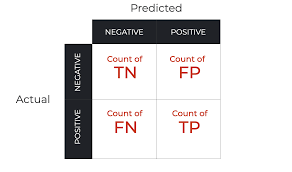


In [ ]:
internally, by defauly, model has following probabilty applied : 

proba = model.predict_proba(X_test)[:,1]
y_pred = (proba > 0.5)



In [ ]:
        pred = (proba > 0.5).astype(int)
        
  Class balance/distribution/proportion of the target is: target_5
0    0.522562
1    0.477438
Name: proportion, dtype: float64

        Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613
        Probability config is set to : 0.5

Precision on top 20%: 0.5164835164835165
Precision on bottom 20%: 0.37362637362637363
accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909

building a hisotrgam which helps to assess where the most volume for both classess is lcoated : 


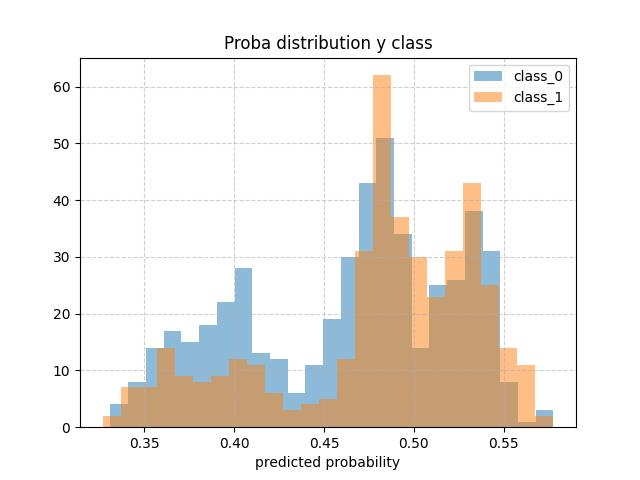

TEsting different options with the probability configs , somehting between ( 0,483 and 0,5) , results below : 

[14 rows x 43 columns]
target_5
0    2374
1    2169
Name: count, dtype: int64
2026-03-23 09:43:20,820 - INFO - 
Class balance/distribution/proportion of the target is: target_5
0    0.522562
1    0.477438
Name: proportion, dtype: float64

        Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613


        >>>>>>>>   Probability config is set to : 0.4833

Precision on top 5 %: 0.6304347826086957
Precision on bottom 5 %: 0.41304347826086957
accuracy_score is : 0.5687568756875687
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[279 212]
 [180 238]]
              precision    recall  f1-score   support

           0       0.61      0.57      0.59       491
           1       0.53      0.57      0.55       418

    accuracy                           0.57       909
   macro avg       0.57      0.57      0.57       909
weighted avg       0.57      0.57      0.57       909





vs 



Class balance/distribution/proportion of the target is: target_5
0    0.522562
1    0.477438
Name: proportion, dtype: float64

        Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 4, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613

       >>>>>>>>>>>> Probability config is set to : 0.5

Precision on top 5 %: 0.6304347826086957
Precision on bottom 5 %: 0.41304347826086957
accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909

now testing the difference in the sample applied in the top and bottom volume. 

top 20 % 

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613
        Probability config is set to : 0.5

Precision on top 20 %: 0.5164835164835165
Sum of top is 182

Precision on bottom 20 %: 0.37362637362637363
bottom of top is 182

accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909




top 10 % 
        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613
        Probability config is set to : 0.5

Precision on top 10 %: 0.5274725274725275
Sum of top is 91

Precision on bottom 10 %: 0.42857142857142855
bottom of top is 91

accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909



top 5 % 

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613
        Probability config is set to : 0.5

Precision on top 5 %: 0.6304347826086957
Sum of top is 46

Precision on bottom 5 %: 0.41304347826086957
bottom of top is 46

accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909



top 2 % 

        proba.min:0.3269655473169245,
        proba.max: 0.57754207023613
        Probability config is set to : 0.5

Precision on top 2 %: 0.7894736842105263
Sum of top is 19

Precision on bottom 2 %: 0.47368421052631576
bottom of top is 19

accuracy_score is : 0.5665566556655666
Train accuracy is : 0.6538249862410567
Test accuracy is : 0.5665566556655666
[[345 146]
 [248 170]]
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       491
           1       0.54      0.41      0.46       418

    accuracy                           0.57       909
   macro avg       0.56      0.55      0.55       909
weighted avg       0.56      0.57      0.56       909


results are promising with :   

 top_threshold=98
 bottom_threshold=100-top_threshold 

 results are : 

Precision on top 2 %: 0.7894736842105263
Sum of top is 19

Precision on bottom 2 %: 0.47368421052631576
bottom of top is 19

lets use now : from sklearn.model_selection import TimeSeriesSplit

before additioal feature engineering : 

  Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

        proba.min:0.3917400059958236,
        proba.max: 0.5666725416236279
        Probability config is set to : 0.5

Hit top rate is  8 %: 0.5806451612903226
Sum of top is 62

Hit bottom rate is 8 %: 0.08064516129032258
bottom of top is 62

accuracy_score is : 0.5785340314136126
Train accuracy is : 0.646481178396072
Test accuracy is : 0.5785340314136126
[[313  95]
 [227 129]]
              precision    recall  f1-score   support

           0       0.58      0.77      0.66       408
           1       0.58      0.36      0.44       356

    accuracy                           0.58       764
   macro avg       0.58      0.56      0.55       764
weighted avg       0.58      0.58      0.56       764



target_5
0    1955
1    1864
Name: count, dtype: int64
2026-03-24 22:27:51,935 - INFO - 
Class balance/distribution/proportion of the target is: target_5
0    0.511914
1    0.488086


 Model name is :  XGBClassifier,
        model details are: {'objective': 'binary:logistic', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.8, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 300, 'n_jobs': None, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': 1, 'reg_lambda': 1, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.8, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}



Name: target_5, Length: 3055, dtype: int64
Hit top rate is  8 %: 0.6451612903225806
Sum of top is 62

Hit bottom rate is 8 %: 0.0967741935483871
bottom of top is 62

accuracy_score is : 0.6178010471204188
Train accuracy is : 0.7482815057283142
Test accuracy is : 0.6178010471204188
[[206 202]
 [ 90 266]]
              precision    recall  f1-score   support

           0       0.70      0.50      0.59       408
           1       0.57      0.75      0.65       356

    accuracy                           0.62       764
   macro avg       0.63      0.63      0.62       764
weighted avg       0.64      0.62      0.61       764

old features , results :     


    Model name is :  RandomForestClassifier,
        model details are: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

        proba.min:0.38749716947068713,
        proba.max: 0.5716650604139166
        Probability config is set to : 0.5

Hit top rate is  8 %: 0.6129032258064516
Sum of top is 62

Hit bottom rate is 8 %: 0.12903225806451613
bottom of top is 62

accuracy_score is : 0.5981675392670157
Train accuracy is : 0.6589198036006547
Test accuracy is : 0.5981675392670157
[[310  98]
 [209 147]]
              precision    recall  f1-score   support

           0       0.60      0.76      0.67       408
           1       0.60      0.41      0.49       356

    accuracy                           0.60       764
   macro avg       0.60      0.59      0.58       764
weighted avg       0.60      0.60      0.59       764



